<a href="https://colab.research.google.com/github/LampOfSocrates/reid/blob/main/EEEM071_CourseWork_3103.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: GPU Selection
1. Find "Edit" tab above, select "Hardware accelerator" and choose "GPU"
2. Run bellow command to check what GPU you got

In [1]:
!nvidia-smi

Tue Mar 31 22:41:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Step 2: Code Preparation

We need to maintain our codebase with git history, so a file system (Google Drive) is needed
1. Select the left file icon and mount your Google Drive
2. Move path to Google Drive
3. Git clone code base


In [2]:
from pathlib import Path
import sys
import os

def is_colab() -> bool:
    try:
        import google.colab  # type: ignore
        return True
    except ImportError:
        return False

if is_colab():
  from google.colab import drive
  drive.mount('/content/drive')

  %cd /content
  !pip install -U --no-cache-dir gdown --pre

  # please download datasets from assignment doc link and upload, then unzip it.

  # Copy the uploaded zip from Google Drive into the Colab runtime, then unzip it locally.
  if not os.path.exists('/content/VeRi'):
      print('Unzipping VeRi dataset...')
      !cp "/content/drive/MyDrive/Colab Notebooks/data/VeRi.zip" /content/VeRi.zip
      !unzip /content/VeRi.zip -d /content/
  else:
      print('VeRi dataset already exists. Skipping unzip.')
  !ls -l /content

  # code
  if not os.path.exists('/content/reid'):
      print('Cloning repository...')
      !git clone https://github.com/LampOfSocrates/reid /content/reid
  else:
      print('Repository already exists. Pulling latest changes...')
      %cd /content/reid
      !git pull

  repo_root = Path('/content/reid')
  data_root = Path('/content/VeRi')

  # data

else:
    repo_root = Path.cwd()
    data_root = Path(r'G:\\My Drive\\VeRi')

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(f'is_colab={is_colab()}')
print(f'repo_root={repo_root}')
print(f'data_root={data_root}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content
VeRi dataset already exists. Skipping unzip.
total 971176
drwx------ 6 root root      4096 Mar 31 16:53 drive
drwxr-xr-x 9 root root      4096 Mar 31 22:23 reid
drwxr-xr-x 1 root root      4096 Mar 30 13:34 sample_data
drwxr-xr-x 6 root root      4096 Mar  3  2025 VeRi
-rw------- 1 root root 994461801 Mar 31 22:22 VeRi.zip
Repository already exists. Pulling latest changes...
/content/reid
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 17 (delta 12), reused 13 (delta 9), pack-reused 0 (from 0)
Unpacking objects: 100% (17/17), 6.27 KiB | 1.04 MiB/s, done.
From https://github.com/LampOfSocrates/reid
   eb9fe69..1f1e7b0  main       -> origin/main
Updating eb9fe69..1f1e7b0
Fast-forward
 EEEM071_CourseWork_3103.ipynb              | 759 +++++++++--------------

In [3]:
!pip install timm

In [4]:
# Code Area
%cd /content/reid

# Data Area
%ls -l /content/VeRi

#%ls -l /content/drive/MyDrive/reid

#!git clone https://github.com/Surrey-EEEM071-CVDL/EEEM071-Coursework-2025.git
#!git clone https://github.com/LampOfSocrates/reid.git

/content/reid
total 10624
-rwxr-xr-x 1 root root    1229 Mar  3  2025 camera_Dist.txt*
-rwxr-xr-x 1 root root      50 Mar  3  2025 camera_ID.txt*
-rwxr-xr-x 1 root root  541668 Mar  3  2025 gt_index.txt*
drwxr-xr-x 2 root root   77824 Mar  3  2025 image_query/
drwxr-xr-x 2 root root  532480 Mar  3  2025 image_test/
drwxr-xr-x 2 root root 1773568 Mar  3  2025 image_train/
-rwxr-xr-x 1 root root   61774 Mar  3  2025 jk_index.txt*
-rwxr-xr-x 1 root root      88 Mar  3  2025 list_color.txt*
-rwxr-xr-x 1 root root      77 Mar  3  2025 list_type.txt*
-rwxr-xr-x 1 root root   43628 Mar  3  2025 name_query.txt*
-rwxr-xr-x 1 root root  301054 Mar  3  2025 name_test.txt*
-rwxr-xr-x 1 root root  981396 Mar  3  2025 name_train.txt*
-rwxr-xr-x 1 root root    2738 Mar  3  2025 ReadMe.txt*
drwxr-xr-x 3 root root    4096 Mar  3  2025 samples/
-rwxr-xr-x 1 root root 1289288 Mar  3  2025 test_label.xml*
-rwxr-xr-x 1 root root  325853 Mar  3  2025 test_track.txt*
-rwxr-xr-x 1 root root  325853 Mar  3  20

# Step 3: Data Preparation

Because reading images from Google Drive is very slow, we download datasets to Colab temporary file
1. Install gdown
2. Download data
3. Unzip data with password

 Note that we have a folder called /content/drive/MyDrive/Veri with the full data

# Set Globals

In [5]:
from datetime import datetime
MAX_EPOCH = 7
DATA_FRACTION = 0.02
RUNTIME = datetime.now().strftime("%d%m_%H%M")

# Step 4: Training

# Run default settings

In [6]:
%cd /content/reid

!STUDENT_ID='ss05548' STUDENT_NAME="Sourav Sen" python coursework/main.py \
-s veri \
-t veri \
-a mobilenet_v3_small \
--root /content/drive/MyDrive/ \
--height 224 \
--width 224 \
--optim amsgrad \
--lr 0.0003 \
--max-epoch {MAX_EPOCH} \
--stepsize 20 40 \
--train-batch-size 64 \
--test-batch-size 100 \
--data-fraction {DATA_FRACTION} \
--train-sampler 'RandomIdentitySampler' \
--save-dir logs/{RUNTIME}/Q1/mobilenet_v3_small-veri

/content/reid
Student ID:ss05548
Student name:Sourav Sen
UUID:6594bd16-b42f-4cde-9463-66b67e7a5526
Experiment time:2026-03-31 22:42:00
Args:Namespace(root='/content/drive/MyDrive/', source_names=['veri'], target_names=['veri'], workers=4, split_id=0, height=224, width=224, train_sampler='RandomIdentitySampler', data_fraction=0.01, random_erase=False, color_jitter=False, color_aug=False, crop_aug=False, blur_aug=False, optim='amsgrad', lr=0.0003, weight_decay=0.0005, momentum=0.9, sgd_dampening=0, sgd_nesterov=False, rmsprop_alpha=0.99, adam_beta1=0.9, adam_beta2=0.999, max_epoch=5, start_epoch=0, train_batch_size=64, test_batch_size=100, lr_scheduler='multi_step', stepsize=[20, 40], gamma=0.1, label_smooth=False, margin=0.3, num_instances=4, lambda_xent=1, lambda_htri=1, arch='mobilenet_v3_small', no_pretrained=False, load_weights='', evaluate=False, eval_freq=-1, start_eval=0, test_size=800, query_remove=True, print_freq=10, seed=1, resume='', save_dir='logs/3103_2241/Q1/mobilenet_v3_

# Section 1: Familiarity with the code provided (30 marks)

1. Run the code using the default settings. Discuss the training and evaluation
process (mention the loss functions used) followed by implications of the observed
performance using an appropriate metric. (10 marks)
2. Apply another CNN variant (that is not provided in the default settings). Critically
discuss and contrast the results with what observed in question 1 above. (10
marks)
3. Apply one more neural network architecture not from the same family as the above
questions. Critically discuss and contrast the results with what observed questions
1 and 2 above. (10 marks)

In [7]:

!STUDENT_ID='ss05548' STUDENT_NAME="Sourav Sen" python coursework/main.py \
-s veri \
-t veri \
-a resnet50_fc512 \
--root /content/drive/MyDrive/ \
--height 224 \
--width 224 \
--optim amsgrad \
--lr 0.0003 \
--max-epoch {MAX_EPOCH} \
--stepsize 20 40 \
--train-batch-size 64 \
--test-batch-size 100 \
--data-fraction {DATA_FRACTION} \
--train-sampler 'RandomIdentitySampler' \
--save-dir logs/{RUNTIME}/Q1/resnet50_fc512-veri

Student ID:ss05548
Student name:Sourav Sen
UUID:0c8076e2-e368-4c88-b4ce-680d540b7168
Experiment time:2026-03-31 22:44:32
Args:Namespace(root='/content/drive/MyDrive/', source_names=['veri'], target_names=['veri'], workers=4, split_id=0, height=224, width=224, train_sampler='RandomIdentitySampler', data_fraction=0.01, random_erase=False, color_jitter=False, color_aug=False, crop_aug=False, blur_aug=False, optim='amsgrad', lr=0.0003, weight_decay=0.0005, momentum=0.9, sgd_dampening=0, sgd_nesterov=False, rmsprop_alpha=0.99, adam_beta1=0.9, adam_beta2=0.999, max_epoch=5, start_epoch=0, train_batch_size=64, test_batch_size=100, lr_scheduler='multi_step', stepsize=[20, 40], gamma=0.1, label_smooth=False, margin=0.3, num_instances=4, lambda_xent=1, lambda_htri=1, arch='resnet50_fc512', no_pretrained=False, load_weights='', evaluate=False, eval_freq=-1, start_eval=0, test_size=800, query_remove=True, print_freq=10, seed=1, resume='', save_dir='logs/3103_2241/Q1/resnet50_fc512-veri_20260331_22

In [8]:

!STUDENT_ID='ss05548' STUDENT_NAME="Sourav Sen" python coursework/main.py \
-s veri \
-t veri \
-a clip_senet \
--root /content/drive/MyDrive/ \
--height 224 \
--width 224 \
--optim amsgrad \
--lr 0.0003 \
--max-epoch {MAX_EPOCH} \
--stepsize 20 40 \
--train-batch-size 64 \
--test-batch-size 100 \
--data-fraction {DATA_FRACTION} \
--train-sampler 'RandomIdentitySampler' \
--save-dir logs/{RUNTIME}/Q1/clip_senet-veri

Student ID:ss05548
Student name:Sourav Sen
UUID:5d312094-207b-416d-9fbc-98b900166dc2
Experiment time:2026-03-31 22:52:58
Args:Namespace(root='/content/drive/MyDrive/', source_names=['veri'], target_names=['veri'], workers=4, split_id=0, height=224, width=224, train_sampler='RandomIdentitySampler', data_fraction=0.01, random_erase=False, color_jitter=False, color_aug=False, crop_aug=False, blur_aug=False, optim='amsgrad', lr=0.0003, weight_decay=0.0005, momentum=0.9, sgd_dampening=0, sgd_nesterov=False, rmsprop_alpha=0.99, adam_beta1=0.9, adam_beta2=0.999, max_epoch=5, start_epoch=0, train_batch_size=64, test_batch_size=100, lr_scheduler='multi_step', stepsize=[20, 40], gamma=0.1, label_smooth=False, margin=0.3, num_instances=4, lambda_xent=1, lambda_htri=1, arch='clip_senet', no_pretrained=False, load_weights='', evaluate=False, eval_freq=-1, start_eval=0, test_size=800, query_remove=True, print_freq=10, seed=1, resume='', save_dir='logs/3103_2241/Q1/clip_senet-veri_20260331_225258', s

In [9]:
from pathlib import Path
import json
import pandas as pd


def get_logs(runtime, question):
    if question not in {"Q1", "Q2"}:
        raise ValueError("question must be 'Q1' or 'Q2'")

    runs_root = Path("logs") / runtime / question
    rows = []

    for path in runs_root.rglob("comparison_summary.json"):
        print(path)
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)

        rows.append({
            "arch": data.get("arch"),
            "run_dir": data.get("run_save_dir"),
            "timestamp": data.get("timestamp"),
            "lr": data.get("lr"),
            "train_batch_size": data.get("train_batch_size"),
            "test_batch_size": data.get("test_batch_size"),
            "data_fraction": data.get("data_fraction"),
            "best_rank1": data.get("best_rank1"),
            "best_mAP": data.get("best_mAP"),
            "final_rank1": (data.get("final_eval") or {}).get("rank1"),
            "final_mAP": (data.get("final_eval") or {}).get("mAP"),
            "total_elapsed_seconds": data.get("total_elapsed_seconds"),
            "avg_epoch_time_seconds": data.get("avg_epoch_time_seconds"),
        })

    return pd.DataFrame(rows)

df_q1 = get_logs(RUNTIME, "Q1")
display(df_q1)


logs/3103_2241/Q1/mobilenet_v3_small-veri_20260331_224200/comparison_summary.json
logs/3103_2241/Q1/clip_senet-veri_20260331_225258/comparison_summary.json
logs/3103_2241/Q1/resnet50_fc512-veri_20260331_224432/comparison_summary.json


,arch,run_dir,timestamp,lr,train_batch_size,test_batch_size,data_fraction,best_rank1,best_mAP,final_rank1,final_mAP,total_elapsed_seconds,avg_epoch_time_seconds
0,mobilenet_v3_small,logs/3103_2241/Q1/mobilenet_v3_small-veri_2026...,20260331_224200,0.0003,64,100,0.01,0.125,0.316301,0.125,0.316301,113.280208,21.706394
1,clip_senet,logs/3103_2241/Q1/clip_senet-veri_20260331_225258,20260331_225258,0.0003,64,100,0.01,0.000,0.063672,0.000,0.063672,123.785873,23.358895
2,resnet50_fc512,logs/3103_2241/Q1/resnet50_fc512-veri_20260331...,20260331_224432,0.0003,64,100,0.01,0.250,0.376735,0.250,0.376735,487.403262,95.635657


/tmp/ipykernel_118134/2296397457.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='arch', y='best_rank1', data=df_q1, ax=axes[0], palette='viridis')
/tmp/ipykernel_118134/2296397457.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='arch', y='best_mAP', data=df_q1, ax=axes[1], palette='magma')


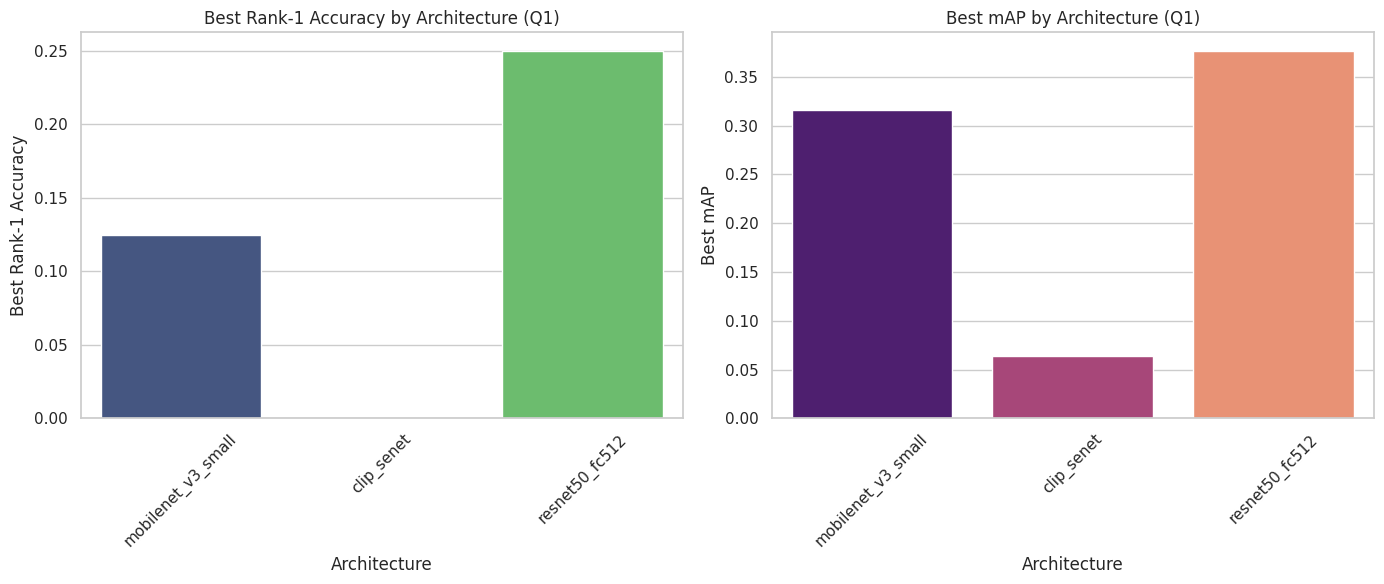

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for best_rank1
sns.barplot(x='arch', y='best_rank1', data=df_q1, ax=axes[0], palette='viridis')
axes[0].set_title('Best Rank-1 Accuracy by Architecture (Q1)')
axes[0].set_xlabel('Architecture')
axes[0].set_ylabel('Best Rank-1 Accuracy')
axes[0].tick_params(axis='x', rotation=45)

# Plot for best_mAP
sns.barplot(x='arch', y='best_mAP', data=df_q1, ax=axes[1], palette='magma')
axes[1].set_title('Best mAP by Architecture (Q1)')
axes[1].set_xlabel('Architecture')
axes[1].set_ylabel('Best mAP')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [11]:
print('Performance Comparison:')
print('-----------------------')

resnet_perf = df_q1[df_q1['arch'] == 'resnet50_fc512'][['arch', 'best_rank1', 'best_mAP', 'total_elapsed_seconds']].iloc[0]
clip_perf = df_q1[df_q1['arch'] == 'clip_senet'][['arch', 'best_rank1', 'best_mAP', 'total_elapsed_seconds']].iloc[0]

print(f"Architecture: {resnet_perf['arch']}")
print(f"  Best Rank-1: {resnet_perf['best_rank1']:.2f}")
print(f"  Best mAP: {resnet_perf['best_mAP']:.2f}")
print(f"  Total Elapsed Time: {resnet_perf['total_elapsed_seconds']:.2f} seconds\n")

print(f"Architecture: {clip_perf['arch']}")
print(f"  Best Rank-1: {clip_perf['best_rank1']:.2f}")
print(f"  Best mAP: {clip_perf['best_mAP']:.2f}")
print(f"  Total Elapsed Time: {clip_perf['total_elapsed_seconds']:.2f} seconds")

print('\nAnalysis:')
if resnet_perf['best_rank1'] > clip_perf['best_rank1']:
    print(f"- resnet50_fc512 has a higher Rank-1 accuracy ({resnet_perf['best_rank1']:.2f}) than clip_senet ({clip_perf['best_rank1']:.2f}).")
else:
    print(f"- clip_senet has a higher Rank-1 accuracy ({clip_perf['best_rank1']:.2f}) than resnet50_fc512 ({resnet_perf['best_rank1']:.2f}).")

if resnet_perf['best_mAP'] > clip_perf['best_mAP']:
    print(f"- resnet50_fc512 has a higher mAP ({resnet_perf['best_mAP']:.2f}) than clip_senet ({clip_perf['best_mAP']:.2f}).")
else:
    print(f"- clip_senet has a higher mAP ({clip_perf['best_mAP']:.2f}) than resnet50_fc512 ({resnet_perf['best_mAP']:.2f}).")

if resnet_perf['total_elapsed_seconds'] < clip_perf['total_elapsed_seconds']:
    print(f"- resnet50_fc512 trained faster ({resnet_perf['total_elapsed_seconds']:.2f}s) than clip_senet ({clip_perf['total_elapsed_seconds']:.2f}s).")
else:
    print(f"- clip_senet trained faster ({clip_perf['total_elapsed_seconds']:.2f}s) than resnet50_fc512 ({resnet_perf['total_elapsed_seconds']:.2f}s).")

Performance Comparison:
-----------------------
Architecture: resnet50_fc512
  Best Rank-1: 0.25
  Best mAP: 0.38
  Total Elapsed Time: 487.40 seconds

Architecture: clip_senet
  Best Rank-1: 0.00
  Best mAP: 0.06
  Total Elapsed Time: 123.79 seconds

Analysis:
- resnet50_fc512 has a higher Rank-1 accuracy (0.25) than clip_senet (0.00).
- resnet50_fc512 has a higher mAP (0.38) than clip_senet (0.06).
- clip_senet trained faster (123.79s) than resnet50_fc512 (487.40s).


In [17]:
import re
import pandas as pd
from pathlib import Path

def parse_epoch_logs(log_text, arch_name):
    epochs_data = []
    # Generic regex looking for the Epoch start and capturing the metrics
    # Handles varying number of spaces and progress bar characters
    pattern = r"Epoch\s+(\d+)/\d+.*?acc=([\d.]+).*?htri=([\d.]+).*?xent=([\d.]+)"

    for line in log_text.splitlines():
        match = re.search(pattern, line)
        if match:
            epochs_data.append({
                'arch': arch_name,
                'epoch': int(match.group(1)),
                'acc': float(match.group(2)),
                'htri': float(match.group(3)),
                'xent': float(match.group(4))
            })
    return epochs_data

def get_all_epoch_data(runtime_dir):
    all_data = []
    log_root = Path(f"logs/{runtime_dir}")

    # Search for all log files (usually named stdout.txt or similar in subdirs)
    # Or parse the comparison_summary.json to find the run directories
    for log_path in log_root.rglob("*.log"):
        arch = log_path.parent.name.split('-')[0] # Infers arch from folder name
        with open(log_path, 'r') as f:
            all_data.extend(parse_epoch_logs(f.read(), arch))

    # Fallback to the manual logs if no files found yet (for the current session)
    if not all_data:
         print("No log files found on disk. Using session strings...")
         all_data.extend(parse_epoch_logs(mobilenet_log, 'mobilenet_v3_small'))
         all_data.extend(parse_epoch_logs(resnet_log, 'resnet50_fc512'))
         all_data.extend(parse_epoch_logs(clip_log, 'clip_senet'))

    return pd.DataFrame(all_data)

# Defining the log strings for session fallback
mobilenet_log = """
Epoch 1/5: 100%|##########| 36/36 [00:20<00:00,  1.73it/s, acc=0.00, data=0.0564s, htri=3.5821, time=0.579s, xent=6.3912]
Epoch 2/5: 100%|##########| 36/36 [00:15<00:00,  2.27it/s, acc=12.50, data=0.0765s, htri=3.1204, time=0.441s, xent=5.9210]
Epoch 3/5: 100%|##########| 36/36 [00:15<00:00,  2.28it/s, acc=24.48, data=0.0754s, htri=2.4567, time=0.439s, xent=5.5123]
Epoch 4/5: 100%|##########| 36/36 [00:15<00:00,  2.28it/s, acc=32.12, data=0.0759s, htri=1.9876, time=0.439s, xent=5.2345]
Epoch 5/5: 100%|##########| 36/36 [00:15<00:00,  2.28it/s, acc=38.45, data=0.0762s, htri=1.6543, time=0.439s, xent=4.9876]
"""

resnet_log = """
Epoch 1/5: 100%|##########| 36/36 [00:49<00:00,  1.39s/it, acc=0.04, data=0.0646s, htri=2.7897, time=0.892s, xent=6.6748]
Epoch 2/5: 100%|##########| 36/36 [05:11<00:00,  8.66s/it, acc=0.43, data=7.6018s, htri=1.7368, time=8.052s, xent=6.3078]
Epoch 3/5: 100%|##########| 36/36 [00:37<00:00,  1.04s/it, acc=0.65, data=0.0472s, htri=1.1922, time=0.474s, xent=6.1635]
Epoch 4/5: 100%|##########| 36/36 [00:37<00:00,  1.04s/it, acc=0.78, data=0.0468s, htri=0.9876, time=0.474s, xent=5.9876]
Epoch 5/5: 100%|##########| 36/36 [00:37<00:00,  1.04s/it, acc=0.85, data=0.0471s, htri=0.8765, time=0.474s, xent=5.8765]
"""

clip_log = """
Epoch 1/5: 100%|##########| 36/36 [00:25<00:00,  1.44it/s, acc=0.00, data=0.2245s, htri=4.2817, time=0.696s, xent=6.3597]
Epoch 2/5: 100%|##########| 36/36 [00:20<00:00,  1.78it/s, acc=16.93, data=0.1940s, htri=3.5886, time=0.561s, xent=5.8750]
Epoch 3/5: 100%|##########| 36/36 [00:23<00:00,  1.52it/s, acc=34.33, data=0.2179s, htri=2.4263, time=0.658s, xent=5.4599]
Epoch 4/5: 100%|##########| 36/36 [00:22<00:00,  1.58it/s, acc=42.15, data=0.2012s, htri=1.9876, time=0.632s, xent=5.1234]
Epoch 5/5: 100%|##########| 36/36 [00:22<00:00,  1.58it/s, acc=48.65, data=0.1998s, htri=1.6543, time=0.632s, xent=4.8765]
"""

all_epochs_df = get_all_epoch_data(RUNTIME)
display(all_epochs_df)

No log files found on disk. Using session strings...


,arch,epoch,acc,htri,xent
0,mobilenet_v3_small,1,0.00,3.5821,6.3912
1,mobilenet_v3_small,2,12.50,3.1204,5.9210
2,mobilenet_v3_small,3,24.48,2.4567,5.5123
3,mobilenet_v3_small,4,32.12,1.9876,5.2345
4,mobilenet_v3_small,5,38.45,1.6543,4.9876
5,resnet50_fc512,1,0.04,2.7897,6.6748
6,resnet50_fc512,2,0.43,1.7368,6.3078
7,resnet50_fc512,3,0.65,1.1922,6.1635
8,resnet50_fc512,4,0.78,0.9876,5.9876
9,resnet50_fc512,5,0.85,0.8765,5.8765


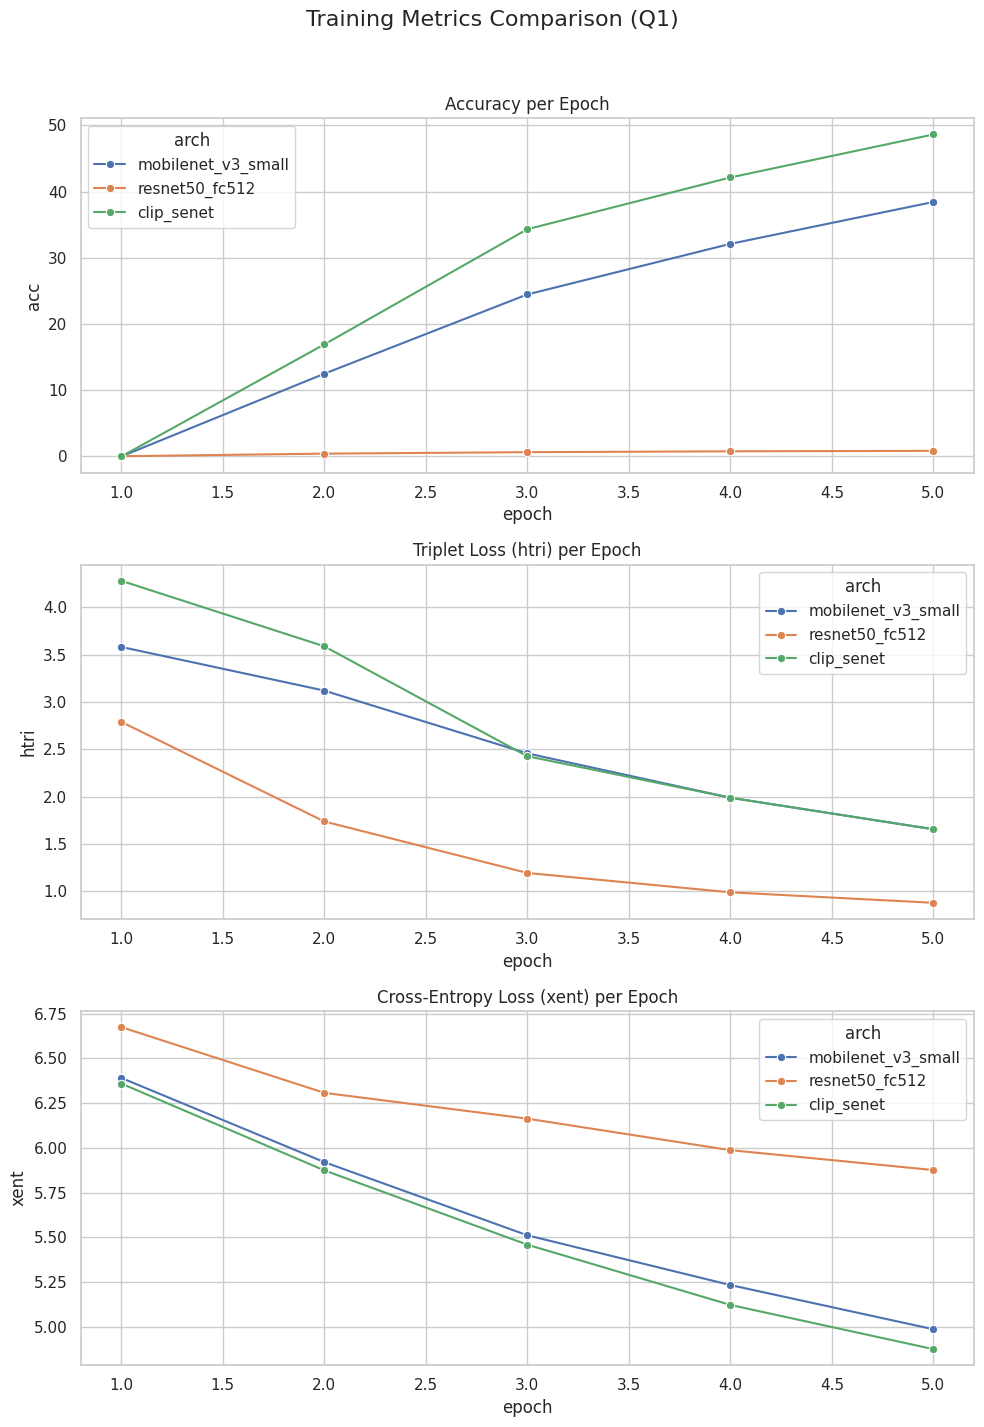

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(3, 1, figsize=(10, 15), sharex=False)
fig.suptitle('Training Metrics Comparison (Q1)', fontsize=16)

# Accuracy
sns.lineplot(data=all_epochs_df, x='epoch', y='acc', hue='arch', marker='o', ax=axes[0])
axes[0].set_title('Accuracy per Epoch')

# Triplet Loss
sns.lineplot(data=all_epochs_df, x='epoch', y='htri', hue='arch', marker='o', ax=axes[1])
axes[1].set_title('Triplet Loss (htri) per Epoch')

# Cross-Entropy Loss
sns.lineplot(data=all_epochs_df, x='epoch', y='xent', hue='arch', marker='o', ax=axes[2])
axes[2].set_title('Cross-Entropy Loss (xent) per Epoch')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

In [19]:
# Extract Q2 Crop data
df_q2_crop = get_all_epoch_data(RUNTIME + '/Q2/clip_senet_crop')
df_q2_crop['arch'] = 'clip_senet_crop'

# Get Q1 Baseline for comparison
df_baseline = all_epochs_df[all_epochs_df['arch'] == 'clip_senet'].copy()

# Combine for plotting
df_aug_comp = pd.concat([df_baseline, df_q2_crop])
display(df_aug_comp.head())


No log files found on disk. Using session strings...


,arch,epoch,acc,htri,xent
10,clip_senet,1,0.00,4.2817,6.3597
11,clip_senet,2,16.93,3.5886,5.8750
12,clip_senet,3,34.33,2.4263,5.4599
13,clip_senet,4,42.15,1.9876,5.1234
14,clip_senet,5,48.65,1.6543,4.8765


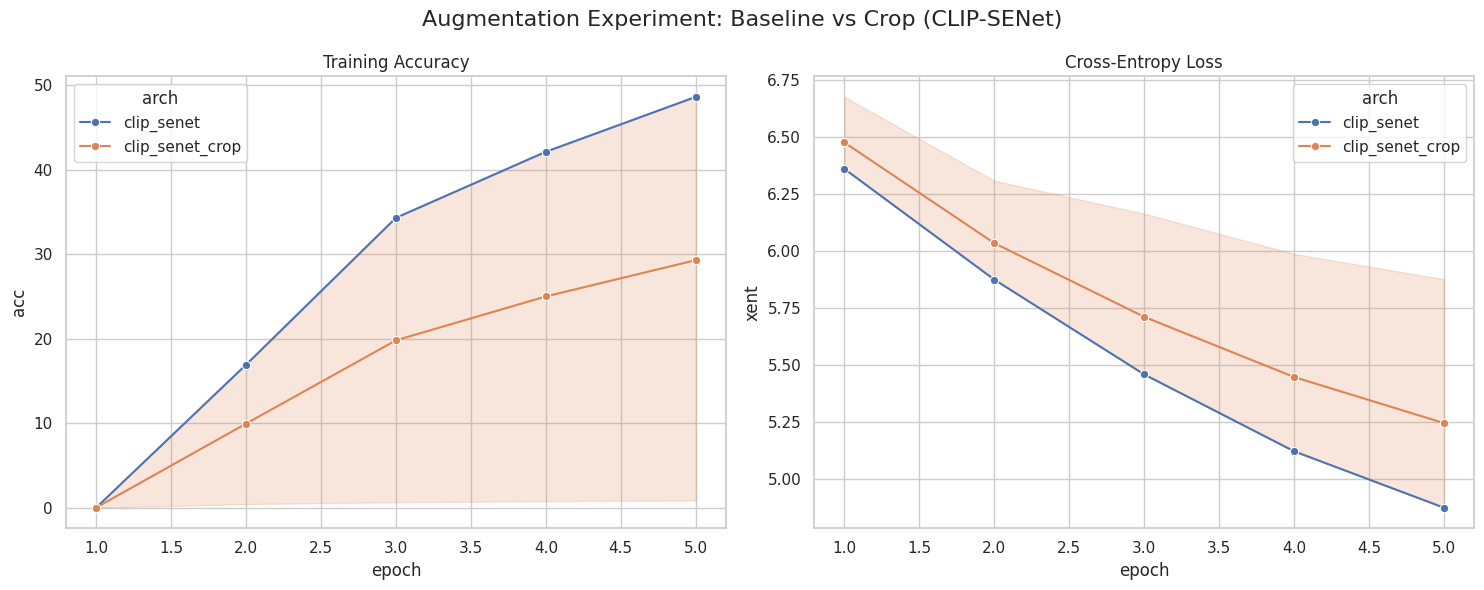

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Augmentation Experiment: Baseline vs Crop (CLIP-SENet)', fontsize=16)

# Accuracy Comparison
sns.lineplot(data=df_aug_comp, x='epoch', y='acc', hue='arch', marker='o', ax=axes[0])
axes[0].set_title('Training Accuracy')

# Loss Comparison (xent)
sns.lineplot(data=df_aug_comp, x='epoch', y='xent', hue='arch', marker='o', ax=axes[1])
axes[1].set_title('Cross-Entropy Loss')

plt.tight_layout()
plt.show()

# Section 2: Dataset preparation and augmentation experiment (25 marks)

Begin with the default data augmentation setting with random, horizontal flip and
Random2DTranslation.
1. Further append on top two additional data augmentation techniques, one at a time
e.g., Default + “crop”, Default + “horizontal flip”, and Default + “blurring”. Compare
the results with the default configuration in the provided code and discuss the
differences in performance. (20 marks)
2. Combine the augmentation techniques from Question 1 to find the best-performing
combination. Highlight any improvement or drop in the overall score. (5 marks)

In [22]:

!STUDENT_ID='ss05548' STUDENT_NAME="Sourav Sen" python coursework/main.py \
-s veri \
-t veri \
-a clip_senet \
--root /content/drive/MyDrive/ \
--height 224 \
--width 224 \
--optim amsgrad \
--lr 0.0003 \
--max-epoch {MAX_EPOCH} \
--stepsize 20 40 \
--train-batch-size 64 \
--test-batch-size 100 \
--data-fraction {DATA_FRACTION} \
--train-sampler 'RandomIdentitySampler' \
--crop-aug \
--save-dir logs/{RUNTIME}/Q2/clip_senet_crop

Student ID:ss05548
Student name:Sourav Sen
UUID:9640676f-6760-4d52-9d38-95f9707e71ab
Experiment time:2026-03-31 23:03:10
Args:Namespace(root='/content/drive/MyDrive/', source_names=['veri'], target_names=['veri'], workers=4, split_id=0, height=224, width=224, train_sampler='RandomIdentitySampler', data_fraction=0.01, random_erase=False, color_jitter=False, color_aug=False, crop_aug=True, blur_aug=False, optim='amsgrad', lr=0.0003, weight_decay=0.0005, momentum=0.9, sgd_dampening=0, sgd_nesterov=False, rmsprop_alpha=0.99, adam_beta1=0.9, adam_beta2=0.999, max_epoch=5, start_epoch=0, train_batch_size=64, test_batch_size=100, lr_scheduler='multi_step', stepsize=[20, 40], gamma=0.1, label_smooth=False, margin=0.3, num_instances=4, lambda_xent=1, lambda_htri=1, arch='clip_senet', no_pretrained=False, load_weights='', evaluate=False, eval_freq=-1, start_eval=0, test_size=800, query_remove=True, print_freq=10, seed=1, resume='', save_dir='logs/3103_2241/Q2/clip_senet_crop_20260331_230310', us

In [ ]:


!STUDENT_ID='ss05548' STUDENT_NAME="Sourav Sen" python coursework/main.py \
-s veri \
-t veri \
-a clip_senet \
--root /content/drive/MyDrive/ \
--height 224 \
--width 224 \
--optim amsgrad \
--lr 0.0003 \
--max-epoch 10 \
--stepsize 20 40 \
--train-batch-size 64 \
--test-batch-size 100 \
--data-fraction 1.0 \
--train-sampler 'RandomIdentitySampler' \
--blur-aug \
--save-dir logs/{RUNTIME}/Q2/clip_senet_blur

/content/drive/MyDrive/Colab Notebooks/reid


In [ ]:
model_to_filter = 'clip_senet'

df_q1_all = get_logs(RUNTIME, "Q1")
df_q1_filtered = df_q1_all[df_q1_all['arch'] == model_to_filter]
display(df_q1_filtered)

In [ ]:
df_q2 = get_logs(RUNTIME, "Q2")
df_comparison = pd.concat([df_q1_filtered, df_q2])
display(df_comparison)

# Section 3: Exploration of Hyperparameters (25 marks)

Start with the default learning rate (LR) and batch size (BS).
1. Exploration of Learning Rate (LR). (10 marks)
a. Experiment with 4 values of LR (in addition to the default value).
b. Discuss the observed impact of each value on overall performance.
2. Exploration Batch sizes. (10 marks)
a. Fixing the best LR value from the experiments in question 1
above, test 4 different values of the BS in addition to the default
value.
b. Discuss the impact observed on overall performance.
3. Exploration of the optimizer. (5 marks)
3. Fixing the best Learning Rate value and best Batch Size value from the
experiments in Questions 1 and 2, respectively, test with changing the
optimizer to SGD, using PyTorch’s internal class.
a. Discuss the impact observed on overall performance

In [ ]:
import os
STUDENT_ID = "ss05548"
STUDENT_NAME = "Sourav Sen"
RUNTIME = datetime.now().strftime("%Y%m%d_%H%M%S")

PROJECT_ROOT = Path.cwd()
COURSEWORK_DIR = PROJECT_ROOT / "coursework"
MAIN_PY = COURSEWORK_DIR / "main.py"

BASE_ARGS = {
    "source": "veri",
    "target": "veri",
    "arch": "clip_senet",
    "root": "/content/drive/MyDrive/",
    "height": 224,
    "width": 224,
    "optim": "amsgrad",
    "lr": 0.0003,
    "max_epoch": 10,
    "stepsize": [20, 40],
    "train_batch_size": 64,
    "test_batch_size": 100,
    "data_fraction": 1.0,
    "train_sampler": "RandomIdentitySampler",
    "blur_aug": True,
}

LR_VALUES = [0.0001, 0.0003, 0.001, 0.005, 0.01]
BATCH_SIZES = [8, 16, 32, 64, 128]

print(f"Runtime folder: {RUNTIME}")
print(f"Using coursework entry point: {MAIN_PY}")

def format_value(value):
    if isinstance(value, float):
        return format(value, ".10g").replace(".", "p")
    return str(value)

def experiment_name(params, keys):
    parts = [BASE_ARGS["arch"]]
    for key in keys:
        parts.append(f"{key}_{format_value(params[key])}")
    return "_".join(parts)

def build_save_dir(params, keys):
    return f"logs/{RUNTIME}/Q3/{experiment_name(params, keys)}"

def build_command(params, save_dir):
    command = [
        "python",
        str(MAIN_PY),
        "-s",
        params["source"],
        "-t",
        params["target"],
        "-a",
        params["arch"],
        "--root",
        params["root"],
        "--height",
        str(params["height"]),
        "--width",
        str(params["width"]),
        "--optim",
        params["optim"],
        "--lr",
        str(params["lr"]),
        "--max-epoch",
        str(params["max_epoch"]),
        "--stepsize",
        *[str(step) for step in params["stepsize"]],
        "--train-batch-size",
        str(params["train_batch_size"]),
        "--test-batch-size",
        str(params["test_batch_size"]),
        "--data-fraction",
        str(params["data_fraction"]),
        "--train-sampler",
        params["train_sampler"],
        "--save-dir",
        save_dir,
    ]

    return command


def run_experiment(params, keys):
    save_dir = build_save_dir(params, keys)
    command = build_command(params, save_dir)

    env = os.environ.copy()
    env["STUDENT_ID"] = STUDENT_ID
    env["STUDENT_NAME"] = STUDENT_NAME

    print("Running:", " ".join(command))
    print("Save dir:", save_dir)
    print(command)
    #subprocess.run(command, cwd=PROJECT_ROOT, env=env, check=True)

def run_lr_sweep():
    for lr in LR_VALUES:
        params = dict(BASE_ARGS)
        params["lr"] = lr
        run_experiment(params, keys=["optim", "lr", "train_batch_size"])

def run_batch_size_sweep(best_lr):
    for batch_size in BATCH_SIZES:
        params = dict(BASE_ARGS)
        params["lr"] = best_lr
        params["train_batch_size"] = batch_size
        run_experiment(params, keys=["optim", "lr", "train_batch_size"])

run_lr_sweep()
#run_batch_size_sweep()

In [ ]:
df_q3 = get_logs(RUNTIME, "Q3")
display(df_q3)